# Modelado de la Distribución Espectral de Energía (SED) del sistema binario AS 205 S.

**Curso:** Modelamiento en Astrofísica 2026

## Introducción
En este proyecto el objetivo es construir un modelo simple para la **Distribución Espectral de Energía (SED)** de un sistema joven con disco protoplanetario, usando como caso de estudio el objeto **AS 205 S**, parte de la muestra **DSHARP** (Disk Substructures at High Angular Resolution Project).
AS 205 S resulta ser un sistema particularmente interesante debido a que el objeto central puede modelarse como una **binaria espectroscópica no resuelta**, de modo que la componente estelar de la SED se representa como la suma de dos cuerpos negros, además de la emisión térmica del disco protoplanetario.

El proyecto sigue los siguientes pasos:

0. Derivación del flujo del disco (fundamentación teórica).
1. Modelo inicial: dos estrellas + disco simple (midplane).
2. Modelo con dos componentes del disco: midplane + capa superficial.
3. Exploración de parámetros.
4. Estructura en anillo o hueco.
6. Optimización de parámetros con MCMC.

Los parámetros estelares y la distancia al sistema se obtienen de **Kurtovic et al. (2018)** y del paralaje de **Gaia DR2** ($d \approx 127$ pc). La ley de extinción interestelar aplicada es la de **Wang & Chen (2019)**.

## 0. Derivación del flujo espectral integrado de un disco protoplanetario

### Los supuestos que consideramos

Para llegar a la expresión del flujo espectral integrado $F_\nu$, se asume lo siguiente:

1. **Disco geométricamente delgado**: la escala de altura $H \ll r$, por lo que cada anillo puede tratarse como una slab plana.
2. **Simetría axial**: las propiedades del disco (temperatura, densidad superficial, opacidad) dependen solo del radio $r$.
3. **Equilibrio termodinámico local (ETL)**: la función fuente es igual a la función de Planck, $S_\nu = B_\nu(T)$.
4. **Sin radiación de fondo**: la intensidad incidente desde el lado opuesto del disco es despreciable, $I_{\nu,0} = 0$.
5. **Disco homogéneo en la dirección vertical**: la opacidad y densidad se integran verticalmente sin variación lateral dentro de cada anillo.
6. **Dispersión despreciable**: el coeficiente de extinción se reduce al de absorción, $\alpha_\nu = \kappa_\nu \rho$.
7. **Temperatura conocida**: el perfil de temperatura radial $T(r)$ se adopta como dado (ley de potencia).
8. **Disco inclinado un ángulo $i$** respecto a la línea de visión: el observador ve el disco proyectado.

---

### 1. Profundidad óptica a través del disco

Consideramos un rayo que atraviesa el disco inclinado un ángulo $i$ respecto al plano del cielo (es decir, $i = 0$ corresponde a disco de cara). El elemento de camino a lo largo de la línea de visión $ds'$ se relaciona con el elemento vertical $dz$ mediante:

$$ds' \cos i = dz \quad \Longrightarrow \quad ds' = \frac{dz}{\cos i}$$

La profundidad óptica se define como:

$$\tau_\nu = \int \alpha_\nu \, ds' = \int \frac{\kappa_\nu \rho}{\cos i} \, dz = \frac{\kappa_\nu}{\cos i} \int_{-\infty}^{\infty} \rho \, dz$$

Reconociendo la densidad superficial $\Sigma(r) = \int_{-\infty}^{\infty} \rho \, dz$, obtenemos:

$$\boxed{\tau_\nu = \frac{\kappa_\nu \, \Sigma(r)}{\cos i}}$$

---

### 2. Ecuación de transferencia radiativa y su solución

La ecuación de transferencia radiativa a lo largo de la coordenada $\tau_\nu$ es:

$$\frac{dI_\nu}{d\tau_\nu} = -I_\nu + S_\nu$$

Bajo la hipótesis de ETL, $S_\nu = B_\nu(T)$, con $T$ constante dentro de cada anillo vertical. Reordenando:

$$\frac{dI_\nu}{d\tau_\nu} + I_\nu = B_\nu(T)$$

Esta es una EDO lineal de primer orden. Multiplicamos por el factor integrante $e^{\tau_\nu}$:

$$e^{\tau_\nu}\frac{dI_\nu}{d\tau_\nu} + e^{\tau_\nu} I_\nu = B_\nu(T)\, e^{\tau_\nu}$$

$$\frac{d}{d\tau_\nu}\!\left(e^{\tau_\nu} I_\nu\right) = B_\nu(T)\, e^{\tau_\nu}$$

Integrando desde $0$ hasta $\tau_\nu$:

$$e^{\tau_\nu} I_\nu - I_{\nu,0} = B_\nu(T) \int_0^{\tau_\nu} e^{\tau'} d\tau' = B_\nu(T)\left(e^{\tau_\nu} - 1\right)$$

Despejando $I_\nu$:

$$I_\nu(\tau_\nu) = I_{\nu,0}\, e^{-\tau_\nu} + B_\nu(T)\left(1 - e^{-\tau_\nu}\right)$$

Aplicando el supuesto de radiación de fondo despreciable ($I_{\nu,0} = 0$):

$$\boxed{I_\nu(\tau_\nu) = B_\nu(T)\!\left(1 - e^{-\tau_\nu}\right)}$$

Este resultado tiene una interpretación física directa: en el límite ópticamente grueso ($\tau_\nu \gg 1$) el disco emite como un cuerpo negro, $I_\nu \to B_\nu(T)$; en el límite ópticamente delgado ($\tau_\nu \ll 1$) la emisión es proporcional a la profundidad óptica, $I_\nu \approx B_\nu(T)\,\tau_\nu$.

---

### 3. Flujo espectral integrado

Consideramos un anillo anular de radio $r$ y ancho $dr$. Su área geométrica es $2\pi r\, dr$, pero el observador la ve proyectada sobre el plano del cielo, de modo que el área aparente es:

$$dA_\perp = 2\pi r \cos i \, dr$$

El ángulo sólido que subtiende este anillo a distancia $d$ es:

$$d\Omega = \frac{dA_\perp}{d^2} = \frac{2\pi r \cos i}{d^2}\, dr$$

El flujo diferencial recibido es $dF_\nu = I_\nu \, d\Omega$. Sustituyendo $I_\nu$ y $\tau_\nu$:

$$dF_\nu = B_\nu(T(r))\!\left[1 - \exp\!\left(-\frac{\kappa_\nu\,\Sigma(r)}{\cos i}\right)\right] \frac{2\pi r \cos i}{d^2}\, dr$$

Integrando sobre todo el disco, desde el borde interno $R_{\min}$ hasta el externo $R_{\max}$:

$$\boxed{F_\nu = \frac{\cos i}{d^2} \int_{R_{\min}}^{R_{\max}} B_\nu(T(r))\!\left[1 - \exp\!\left(-\frac{\kappa_\nu\,\Sigma(r)}{\cos i}\right)\right] 2\pi r\, dr}$$

que es exactamente la expresión solicitada.

---

### Descripción de los términos

| Símbolo | Significado |
|---|---|
| $i$ | Inclinación del disco respecto a la línea de visión ($i=0$: disco de cara) |
| $d$ | Distancia al sistema |
| $R_{\min},\, R_{\max}$ | Radio interno y externo del disco |
| $B_\nu(T(r))$ | Función de Planck evaluada en la temperatura local del disco |
| $\kappa_\nu$ | Opacidad másica del polvo a la frecuencia $\nu$ |
| $\Sigma(r)$ | Densidad superficial del disco |
| $\cos i / d^2$ | Factor geométrico de proyección y dilución con la distancia |
| $1 - e^{-\tau_\nu}$ | Factor de emisividad: interpolación continua entre los regímenes opticamente delgado y grueso |

## 1. Modelo Inicial: dos estrellas + disco simple.
Comenzamos importando las librerías necesarias y leyendo los datos fotométricos de AS 205 S. Seguido, se grafica la SED observada en el espacio $\nu F_\nu \text{ vs. } \lambda$ con ejes logarítmicos, donde logramos visualizar una distribución de energía.

In [1]:
#Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.constants import parsec
import emcee
import corner
from multiprocessing import Pool
import warnings

In [2]:
#Lectura de datos
columns = ["wavelength", "flux", "statistical_error", "systematic_error", "name"]
#wavelenght en micrómetros, flux density en Jy, statistical_error en Jy, systematic_error en %
data = pd.read_csv("AS205.SED.txt", skiprows=10, sep=r"\s+", names=columns)
data

,wavelength,flux,statistical_error,systematic_error,name
0,0.3597,0.00602,0.002610,0.20,Eisner05
1,0.4377,0.01306,0.000720,0.20,Eisner05
2,0.5488,0.02911,0.000800,0.20,Eisner05
3,0.6515,0.05845,0.002150,0.20,Eisner05
4,0.7981,0.15503,0.011420,0.20,Eisner05
5,1.2350,0.95520,0.016700,0.02,2MASS
6,1.6620,2.05070,0.051000,0.02,2MASS
7,2.1590,3.23890,0.050700,0.02,2MASS
8,3.3526,4.42780,0.909400,0.02,WISE
9,4.6028,6.85790,1.579100,0.03,WISE


In [3]:
#Podemos calcular el error total combinando el error estadístico y el sistemático 
#según la literatura dada por AS205.SED.txt
#error = ( col3**2 + (col2*col4)**2 )**0.5

#Consideramos que la columna 3 es el error estadístico y columna 4 es el error sistemático, 
#por lo que el error total se calcula como la raíz cuadrada de la suma de los cuadrados de ambos errores.
error = np.sqrt(data["statistical_error"]**2 + (data["flux"] * data["systematic_error"])**2)
data["total_error"] = error #En Jy
data

,wavelength,flux,statistical_error,systematic_error,name,total_error
0,0.3597,0.00602,0.002610,0.20,Eisner05,0.002874
1,0.4377,0.01306,0.000720,0.20,Eisner05,0.002709
2,0.5488,0.02911,0.000800,0.20,Eisner05,0.005877
3,0.6515,0.05845,0.002150,0.20,Eisner05,0.011886
4,0.7981,0.15503,0.011420,0.20,Eisner05,0.033042
5,1.2350,0.95520,0.016700,0.02,2MASS,0.025374
6,1.6620,2.05070,0.051000,0.02,2MASS,0.065446
7,2.1590,3.23890,0.050700,0.02,2MASS,0.082260
8,3.3526,4.42780,0.909400,0.02,WISE,0.913702
9,4.6028,6.85790,1.579100,0.03,WISE,1.592446


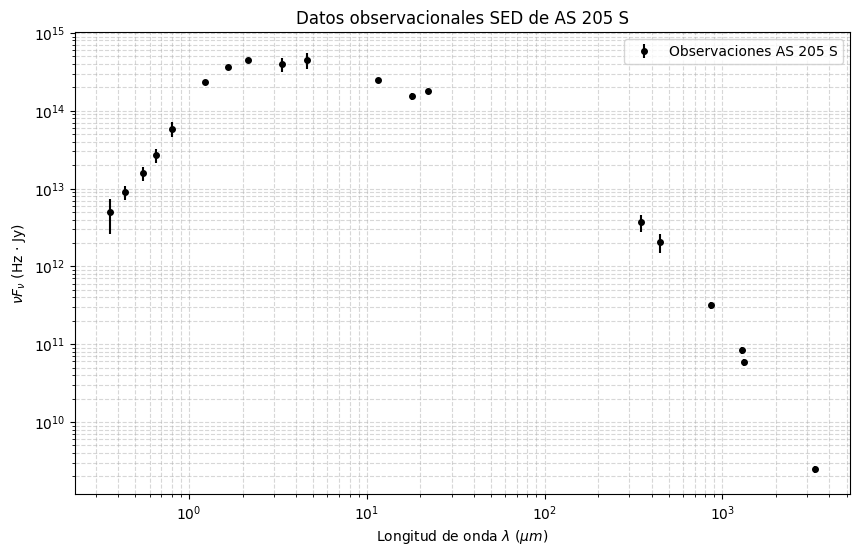

In [4]:
#Anotamos las constantes en CGS, el cual es el sistema que usaremos a lo largo del proyecto
sigma_b = 5.670374419e-5 #Constante de Stefan-Boltzmann en [erg cm^-2 s^-1 K^-4]
k = 1.380649e-16         #Constante de Boltzmann en [erg/K]
h = 6.62607015e-27       #Constante de Planck en [erg·s]
c = 2.99792458e10        #Velocidad de la luz en [cm/s]

#Convertimos la longitud de onda de micrómetros a centimetros para calcular la frecuencia en Hz
wavelength_cm = data["wavelength"] * 1e-4 
frecuencia_hz = c / wavelength_cm

#Calculamos nu * F_nu (en Hz * Jy) y su error propagado
nu_Fnu = frecuencia_hz * data["flux"]
nu_Fnu_error = frecuencia_hz * data["total_error"]

#Graficamos nu * F_nu versus longitud de onda (SED observada)
plt.figure(figsize=(10, 6))
plt.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error, fmt="o", label="Observaciones AS 205 S", color="black", markersize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Longitud de onda $\lambda$ ($\mu m$)")
plt.ylabel(r"$\nu F_\nu$ (Hz $\cdot$ Jy)")
plt.title("Datos observacionales SED de AS 205 S")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

#### Parámetros del sistema
Los parámetros del sistema AS 205 S se obtienen de **Kurtovic et al. (2018)**.
AS 205 S es una binaria espectroscópica no resuelta. Las dos componentes son estrellas de tipo T Tauri con temperaturas y luminosidades distintas. Como estos valores no son precisos en la literatura, hemos decidido adoptar una aproximación basada en los rangos típicos para sistemas T Tauri de baja masa.

In [5]:
#Distancia a AS 205 S
d_pc = 127 #en parsecs
#De parsecs a centímetros
d_cm = d_pc * parsec * 1e2

#Las temperaturas y luminosidades de las estrellas basadas en papers.
T_1, T_2 = 4200.0, 3800.0 #Kelvin

L_sun = 3.828e33 #Luminosidad solar en erg/s
L_1 = 1.0 * L_sun #erg/s (Aproximación estrella 1)
L_2 = 0.4 * L_sun #erg/s (Aproximación estrella 2)

#### Funciones definidas
Se definieron las funciones principales que usaremos durante todo el proyecto:
- `radio_estelar`: obtiene el radio de cada estrella a partir de la ley de Stefan-Boltzmann, $L = 4\pi R^2 \sigma T^4$.
- `planck_function`: la función de Planck $B_\nu(T)$ en CGS.
- `F_nu`: flujo de la binaria como suma de dos cuerpos negros, obtenida en el inciso 0.
- `extincion_wang2019`: corrección de extinción interestelar usando Wang & Chen (2019), que cubre el rango óptico e infrarrojo donde la extinción es más importante. No corregimos en el milimétrico, donde $A_\lambda / A_V \approx 0$.

In [6]:
#Para sacar los radios de las estrellas
def radio_estelar(T, L):
    """
    Calcula el radio de una estrella usando la ley de Stefan-Boltzmann.
    T: temperatura de la estrella en Kelvin (K)
    L: luminosidad de la estrella en Watts (erg/s)
    sigma_b: constante de Stefan-Boltzmann
    """
    return np.sqrt(L / (4 * np.pi * sigma_b * T**4))

#Función de Planck
def planck_function(nu, T):
    """
    Calcula la función de Planck para frecuencia en CGS.
    nu: frecuencia en Hz
    T: temperatura en Kelvin (K)
    k: constante de Boltzmann
    h: constante de Planck
    c: velocidad de la luz
    """
    with np.errstate(over="ignore"): #Ignora advertencias de overflow en la función exponencial
        a = 2*h*(nu**3/c**2)
        b = np.exp((h*nu) / (k*T)) - 1.0
    return a / b

#Función que modela la emisión estelar
def F_nu (R_1, R_2, T_1, T_2, nu, d_cm):
    """
    Calcula el flujo total F_nu de una estrella binaria.
    R_1: radio de la estrella 1
    R_2: radio de la estrella 2
    T_1: temperatura de la estrella 1
    T_2: temperatura de la estrella 2
    planck_function: función de Planck para calcular la emisión de cada estrella
    nu: frecuencia en Hz
    d_cm: distancia a la estrella en centímetros (cm)
    """
    F_star_1 = ((R_1/d_cm)**2) * np.pi * planck_function(nu, T_1)
    F_star_2 = ((R_2/d_cm)**2) * np.pi * planck_function(nu, T_2)
    F_total = F_star_1 + F_star_2

    #Convertimos de SI a Janskys multiplicando por 1e26
    F_total_Jy = F_total * 1e23
    return F_total_Jy

#Función que define la extinción obtenida por Wang et al. 2019
def extincion_wang2019(wave_um, flujo_Jy, A_v=3.0, R_v=3.16):
    """
    Corrección de extinción interestelar usando Wang & Chen (2019).
    Aplicamos la ley en el infrarrojo cercano (0.3 < 1/lambda < 1.1 µm^-1)
    y en el óptico (1.1 <= 1/lambda < 3.3 µm^-1).
    En el milimétrico la extinción es despreciable y no se modifica el flujo.
    wave_um:  longitud de onda [µm]
    flujo_Jy: flujo observado [Jy]
    A_v:      extinción en la banda V [mag]
    R_v:      R_V = A_V / E(B-V)
    Retorna:  flujo corregido [Jy]
    """
    x = 1.0 / wave_um
    a = np.zeros_like(x)
    
    #0.3 < x < 1.1
    ir = (0.3 < x) & (x < 1.1)
    #La ley de potencias ajustada: A_lambda / A_V = 0.3722 * lambda^{-2.07}
    a[ir] = 0.3722 * (x[ir]**2.07)

    #Óptico
    opt = (x >= 1.1) & (x < 3.3)
    y = x[opt] - 1.82
    a[opt] = (1.0 + 0.7499*y - 0.1086*y**2 - 0.08909*y**3
              + 0.02905*y**4 + 0.01069*y**5 + 0.001707*y**6 - 0.001002*y**7)

    A_lambda = A_v * a
    
    return flujo_Jy * 10**(-0.4 * A_lambda)

#### Parámetros de radios y sublimación del polvo

En lugar de fijar un $R_{\min}$ de forma arbitraria, establecemos una estimación donde se impone que la temperatura del polvo en este radio alcanza una temperatura de sublimación  $T_\text{sub}$. Usando el perfil de temperatura radial:

$$T(r) = T_1 \left(\frac{r}{r_1}\right)^{-q} \quad \Longrightarrow \quad R_{\min} = r_1 \left(\frac{T_1}{T_\text{sub}}\right)^{1/q}$$

Con $T_\text{sub} = 1500$ K, $T_1 = 300$ K y $q = 0.75$, obtenemos un $R_{\min}$ del orden de décimas de au, consistente con el borde interno esperado en discos T Tauri. Si $T_\text{sub}$ fuera mayor (polvo más refractario), $R_{\min}$ disminuiría, acercando el borde al objeto central; si fuera menor, el borde se alejaría.

In [7]:
#Definimos unidades astronómicas
AU = 1.496e13 #cm
r1 = AU * 1.0 #El radio definido a una unidad astronómica

#Definimos parámetros "libres" del disco
T1_disco = 300.0 #Temperatura de polvo a un au [K]
sigma1 = 50.0 #Densidad superficial de polvo a un au [g/cm^2]

q1 = 0.75 #Índice espectral de la temperatura del disco
beta = 1.0 #Índice espectral de la opacidad del polvo
k_0 = 10 #coeficiente de opacidad [cm^2/g]
nu_0 = 1e12 #frecuencia de referencia para la opacidad [Hz]

T_sub = 1500.0 #Temperatura de sublimación del polvo [K]
i_deg = 68.0 #Según la literatura, es la inclinación en grados ocupada en modelos MCMC

#Definimos el radio mínimo y máximo del disco
R_min = r1*(T_sub/T1_disco)**(-1.0/q1)
R_max = 80 * AU #Radio externo

print(f"R_min = {R_min/AU:.3f} au")
print(f"R_max = {R_max/AU:.1f} au")

R_min = 0.117 au
R_max = 80.0 au


In [8]:
#Arreglo para los radios en escala logarítmica
r_radio = np.logspace(np.log10(R_min), np.log10(R_max), 1000)

#Definimos las funciones para sigma y la temperatura del disco (perfiles de densidad superficial y temperatura)
def sigma_disco(r):
    """
    Calcula la densidad superficial de polvo en el disco.
    """
    return sigma1 * (r / r1)**(-1.0)

def T_disco(r):
    """
    Calcula la temperatura del disco en función del radio.
    """
    return T1_disco * (r / r1)**(-q1)

In [9]:
#Obtenemos los valores de temperatura y densidad superficial para cada radio
temp_radio = T_disco(r_radio)
sigma_radio = sigma_disco(r_radio)
cos_i = np.cos(np.radians(i_deg))

#### Integración del flujo y aplicación simultánea de la extinción

Para cada punto de los datos, calculamos:
1. El flujo estelar de cada componente ($F_{\nu,\star_1}$ y $F_{\nu,\star_2}$).
2. El flujo del disco integrando numéricamente con `np.trapezoid`.
3. El flujo total intrínseco (estrellas + disco).
4. La corrección de extinción con $A_V = 1.5$ mag, valor adoptado como razonable para la región de Ophiuchus.

La extinción se aplica al flujo total y también a cada componente por separado para poder visualizarlas individualmente en el gráfico.

In [10]:
#Para comenzar con la integración, definimos
frecuencias = frecuencia_hz.values 
#Arreglos para guardar los componentes
F_star1_Jy_arr = np.zeros(len(frecuencias))
F_star2_Jy_arr = np.zeros(len(frecuencias))
F_disco_Jy_arr = np.zeros(len(frecuencias))
F_modelo_Jy = np.zeros(len(frecuencias))

R_1 = radio_estelar(T_1, L_1)
R_2 = radio_estelar(T_2, L_2)

A_v = 1.5 #Extinción visual aproximada

#Forma para calcular la integral
for idx, nu in enumerate(frecuencias):
    #Componentes estelares por separado
    F_star_1 = ((R_1/d_cm)**2) * np.pi * planck_function(nu, T_1) * 1e23
    F_star_2 = ((R_2/d_cm)**2) * np.pi * planck_function(nu, T_2) * 1e23
    f_stars = F_star_1 + F_star_2

    #Disco
    kappa_nu = k_0 * (nu / nu_0)**beta
    tau_nu = (kappa_nu * sigma_radio) #Profundidad óptica (tau)
    
    B_nu = planck_function(nu, T_disco(r_radio))
    
    exponencial = np.exp(-tau_nu / cos_i)
    integrando = B_nu * (1.0 - exponencial) * 2.0 * np.pi * r_radio
    integral_area = np.trapezoid(integrando, r_radio)
    f_disco_cgs= integral_area * (cos_i / d_cm**2)
    
    #Convertimos a Janskys y sumamos al estelar
    f_disco_Jy = f_disco_cgs * 1e23

    #Sumamos ambos flujos
    f_total_intrinseco = f_stars + f_disco_Jy

    #Extinción al total y a cada componente
    F_modelo_Jy[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_total_intrinseco]), A_v=A_v)[0]
    F_star1_Jy_arr[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([F_star_1]), A_v=A_v)[0]
    F_star2_Jy_arr[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([F_star_2]), A_v=A_v)[0]
    F_disco_Jy_arr[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_disco_Jy]), A_v=A_v)[0]

nu_Fnu_modelo = frecuencias * F_modelo_Jy

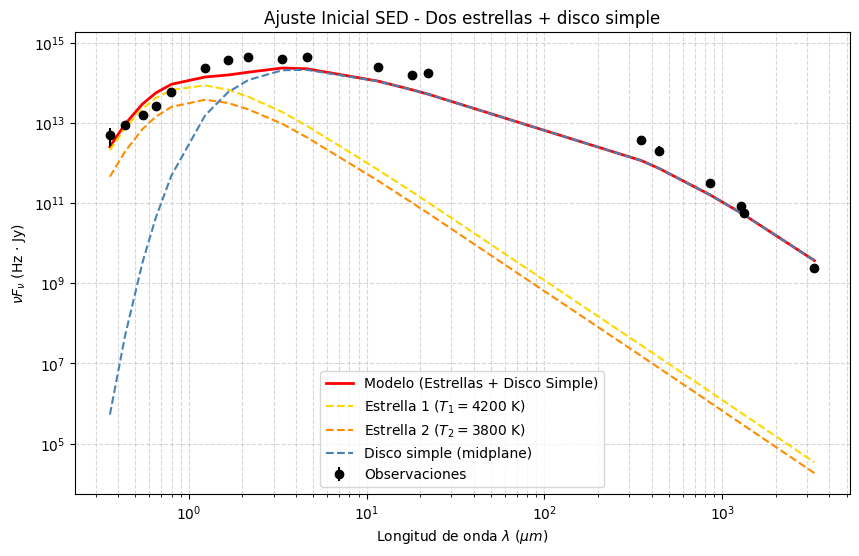

In [11]:
#Graficamos la SED con el modelo y las componentes por separado
plt.figure(figsize=(10, 6))

#Datos observacionales iniciales
plt.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error, fmt="o", label="Observaciones", color="black", zorder=5)

#Modelo teórico
plt.plot(data["wavelength"], nu_Fnu_modelo, ls="-", color="red", label="Modelo (Estrellas + Disco Simple)", linewidth=2)

#Componentes separadas
plt.plot(data["wavelength"], frecuencias * F_star1_Jy_arr,
         ls="--", color="gold", label=rf"Estrella 1 ($T_1={T_1:.0f}$ K)")
plt.plot(data["wavelength"], frecuencias * F_star2_Jy_arr,
         ls="--", color="darkorange", label=rf"Estrella 2 ($T_2={T_2:.0f}$ K)")
plt.plot(data["wavelength"], frecuencias * F_disco_Jy_arr,
         ls="--", color="steelblue", label="Disco simple (midplane)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Longitud de onda $\lambda$ ($\mu m$)")
plt.ylabel(r"$\nu F_\nu$ (Hz $\cdot$ Jy)")
plt.title("Ajuste Inicial SED - Dos estrellas + disco simple")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**Pregunta: ¿En qué rango de longitudes de onda domina la emisión estelar y en cuál domina la emisión del disco?**

La emisión estelar domina en el **óptico e infrarrojo cercano** ($\lambda \lesssim 3\text{–}5\,\mu$ m), donde ambos cuerpos negros a aproximadamente ~4000 K alcanzan su máximo. La emisión del disco comienza a destacarse en el **infrarrojo medio** ($\lambda \sim 5\text{–}30\,\mu$ m) y domina completamente en el **infrarrojo lejano** ($\lambda \gtrsim 50\,\mu$ m), donde el polvo frío de las regiones externas del disco se vuelve la parte dominante.

## 2. Segundo componente del disco: capa superficial.
El modelo de disco plano simple no predice de la mejor manera el exceso de emisión en la parte de infrarrojo medio y lejano. Para poder mejorar esto, agregamos un segundo componente inspirado en **Chiang & Goldreich (1997)**, donde se añade una capa superficial del disco, más caliente que el midplane ya modelado, y que intercepta directamente la radiación estelar y la reemite a temperaturas mayores.

Esta capa tiene un perfil de temperatura más plano ($q_2 = 0.55$, en contraste a $q_1 = 0.75$ del midplane). Se mantiene, sin embargo, el mismo perfil de densidad superficial $\frac{1}{r}$ pero con una normalización distinta que ajustamos para reproducir el exceso observado.

In [12]:
#Para la nueva capa (superficial) del disco, definimos nuevos parámetros libres
T2_disco = 400.0
sigma2 = 5.0
q2 = 0.55

In [13]:
#Definimos las funciones para sigma y la temperatura del disco
def sigma_disco_2(r):
    """
    Calcula la densidad superficial de polvo en el disco.
    """
    return sigma2 * (r / r1)**(-1.0)

def T_disco_2(r):
    """
    Calcula la temperatura del disco en función del radio.
    """
    return T2_disco * (r / r1)**(-q2)

In [14]:
#Los arreglos para cada componente del modelo
F_modelo_total_Jy = np.zeros(len(frecuencias))
F_solo_estrellas_ext = np.zeros(len(frecuencias))
F_midplane_ext = np.zeros(len(frecuencias))
F_capa_ext = np.zeros(len(frecuencias))
F_star1_ext = np.zeros(len(frecuencias))
F_star2_ext = np.zeros(len(frecuencias))

for idx, nu in enumerate(frecuencias):

    kappa_nu = k_0 * (nu / nu_0)**beta

    f_star1_Jy = ((R_1/d_cm)**2) * np.pi * planck_function(nu, T_1) * 1e23
    f_star2_Jy = ((R_2/d_cm)**2) * np.pi * planck_function(nu, T_2) * 1e23
    f_stars_Jy = f_star1_Jy + f_star2_Jy
    
    #Midplane (Disco 1)
    tau_1 = kappa_nu * sigma_disco(r_radio)
    B_nu_1 = planck_function(nu, T_disco(r_radio))
    int_1 = B_nu_1 * (1.0 - np.exp(-tau_1 / cos_i)) * 2.0 * np.pi * r_radio
    f_disco_1_cgs = np.trapezoid(int_1, r_radio) * (cos_i / d_cm**2)
    f_disco_1_Jy = f_disco_1_cgs * 1e23

    #Capa superficial
    tau_2 = kappa_nu * sigma_disco_2(r_radio)
    B_nu_2 = planck_function(nu, T_disco_2(r_radio))
    int_2 = B_nu_2 * (1.0 - np.exp(-tau_2 / cos_i)) * 2.0 * np.pi * r_radio
    f_disco_2_cgs = np.trapezoid(int_2, r_radio) * (cos_i / d_cm**2)
    f_disco_2_Jy = f_disco_2_cgs * 1e23
    
    #Sumamos los flujos por separado antes de aplicar la extinción
    f_total_intrinsico = f_stars_Jy + f_disco_1_Jy + f_disco_2_Jy
    
    #Aplicamos la extinción para nuestro f_total
    f_total_ext = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_total_intrinsico]), A_v=A_v)[0]
    F_modelo_total_Jy[idx] = f_total_ext
    
    #Ahora aplicamos la extinción a cada componente por separado para poder graficar sus contribuciones
    F_modelo_total_Jy[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_total_intrinsico]), A_v=A_v)[0]
    F_solo_estrellas_ext[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_stars_Jy]), A_v=A_v)[0]
    F_star1_ext[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_star1_Jy]), A_v=A_v)[0]
    F_star2_ext[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_star2_Jy]), A_v=A_v)[0]
    F_midplane_ext[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_disco_1_Jy]), A_v=A_v)[0]
    F_capa_ext[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_disco_2_Jy]), A_v=A_v)[0]

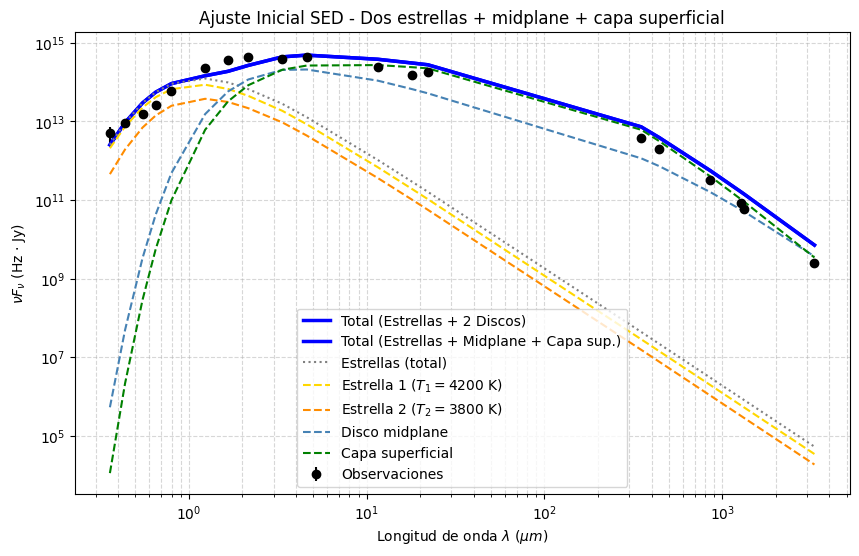

In [15]:
#Gráfico del modelo con ambos discos y las contribuciones por separado
plt.figure(figsize=(10, 6))

#Datos observacionales iniciales
plt.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error, fmt="o", label="Observaciones", color="black")

#Modelo total (estrellas + ambos discos)
plt.plot(data["wavelength"], frecuencias * F_modelo_total_Jy, ls="-", color="blue", label="Total (Estrellas + 2 Discos)", linewidth=2.5)

#Graficamos las contribuciones separadas para una mejor visualización
plt.plot(data["wavelength"], frecuencias * F_modelo_total_Jy,
         ls="-", color="blue", label="Total (Estrellas + Midplane + Capa sup.)", linewidth=2.5)
plt.plot(data["wavelength"], frecuencias * F_solo_estrellas_ext,
         ls=":", color="gray", label="Estrellas (total)")
plt.plot(data["wavelength"], frecuencias * F_star1_ext,
         ls="--", color="gold", label=rf"Estrella 1 ($T_1={T_1:.0f}$ K)")
plt.plot(data["wavelength"], frecuencias * F_star2_ext,
         ls="--", color="darkorange", label=rf"Estrella 2 ($T_2={T_2:.0f}$ K)")
plt.plot(data["wavelength"], frecuencias * F_midplane_ext,
         ls="--", color="steelblue", label="Disco midplane")
plt.plot(data["wavelength"], frecuencias * F_capa_ext,
         ls="--", color="green", label="Capa superficial")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Longitud de onda $\lambda$ ($\mu m$)")
plt.ylabel(r"$\nu F_\nu$ (Hz $\cdot$ Jy)")
plt.title("Ajuste Inicial SED - Dos estrellas + midplane + capa superficial")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**Pregunta: ¿Qué componente explica mejor el MIR/FIR y por qué?**

La capa superficial explica mejor el exceso en el infrarrojo medio y lejano. Su temperatura ($T_2 > T_1$) y su índice más plano ($q_2 = 0.55$) hacen que emita eficientemente a longitudes de onda intermedias, llenando ese exceso que el midplane inicial no podía reproducir de la mejor forma. Físicamente, la capa superficial es la zona del disco que intercepta directamente la radiación estelar y la reemite con poca profundidad óptica.

## 3. Exploración de parámetros.

Usando el modelo de las dos estrellas más el midplane y la capa superficial realizada en el inciso 2, es que exploramos tres casos:
1. Índice de opacidad $\beta$
2. Radios  $R_{\min}$ y $R_{\max}$
3. Razón de luminosidades $L_1/L_2$

Y para poder facilitar el proceso de comparación es que colocamos las funciones y las definiciones necesarias del modelo dentro de una función reutilizable según nuestras variables.

In [16]:
#Definimos una función donde podamos variar los parámetros de ambos discos y obtener el modelo total de la SED
def modelo_SED(frecuencias, data, T_1, T_2, R_1, R_2, d_cm, cos_i,
               T1_disco, sigma1, q1,
               T2_disco, sigma2, q2,
               beta, R_min, R_max, A_v=1.5, N=1000):
    """
    Calcula el modelo total de la SED (estrellas + midplane + capa superficial).
    Retorna nu*F_nu extinguido para cada punto de data.
    """
    r_radio = np.logspace(np.log10(R_min), np.log10(R_max), N)
    
    def T_mid(r): return T1_disco * (r / r1)**(-q1)
    def sig_mid(r): return sigma1 * (r / r1)**(-1.0)
    def T_sup(r): return T2_disco * (r / r1)**(-q2)
    def sig_sup(r): return sigma2 * (r / r1)**(-1.0)

    F_total_Jy = np.zeros(len(frecuencias))

    for idx, nu in enumerate(frecuencias):
        kappa_nu = k_0 * (nu / nu_0)**beta

        #Las estrellas
        f_s1 = ((R_1/d_cm)**2) * np.pi * planck_function(nu, T_1) * 1e23
        f_s2 = ((R_2/d_cm)**2) * np.pi * planck_function(nu, T_2) * 1e23

        #El Midplane
        tau1 = kappa_nu * sig_mid(r_radio)
        int1 = planck_function(nu, T_mid(r_radio)) * (1 - np.exp(-tau1/cos_i)) * 2*np.pi*r_radio
        f_mid = np.trapezoid(int1, r_radio) * (cos_i / d_cm**2) * 1e23

        #La Capa superficial
        tau2 = kappa_nu * sig_sup(r_radio)
        int2 = planck_function(nu, T_sup(r_radio)) * (1 - np.exp(-tau2/cos_i)) * 2*np.pi*r_radio
        f_sup = np.trapezoid(int2, r_radio) * (cos_i / d_cm**2) * 1e23

        f_tot = f_s1 + f_s2 + f_mid + f_sup
        F_total_Jy[idx] = extincion_wang2019(np.array([data["wavelength"].iloc[idx]]), np.array([f_tot]), A_v=A_v)[0]

    return frecuencias * F_total_Jy

#Creamos un diccionario donde están los parámetros base del modelo que teníamos previamente ajustado.
params_base = dict(
    T_1=T_1, T_2=T_2, R_1=R_1, R_2=R_2, d_cm=d_cm, cos_i=cos_i,
    T1_disco=T1_disco, sigma1=sigma1, q1=q1,
    T2_disco=T2_disco, sigma2=sigma2, q2=q2,
    beta=beta, R_min=R_min, R_max=R_max, A_v=1.5
)

modelo_base = modelo_SED(frecuencias, data, **params_base)

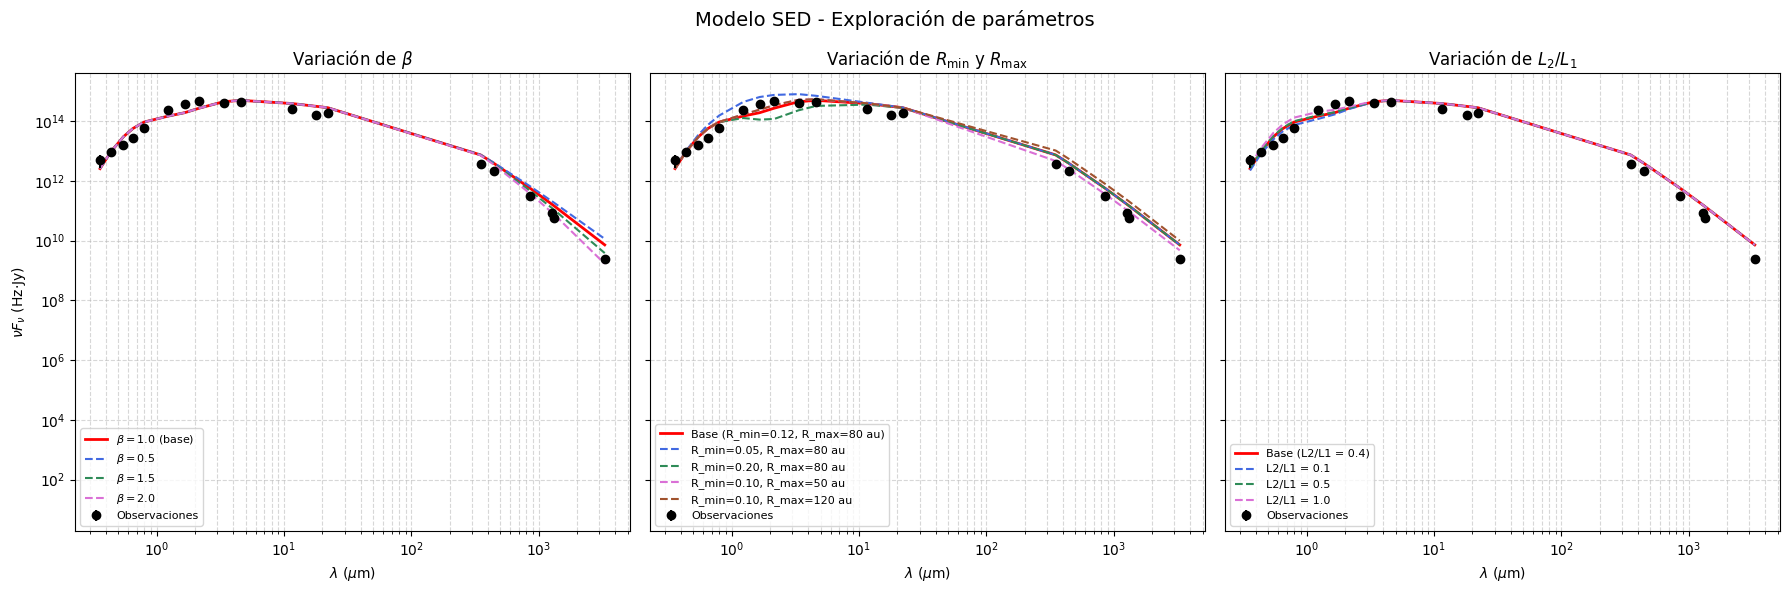

In [17]:
#La mejos forma de visualizar sería con tres subplots para comparar más cómodamente
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("Modelo SED - Exploración de parámetros", fontsize=14)

#Plot 1: Variación del índice de opacidad beta
ax = axes[0]
ax.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error,
            fmt="o", color="black", label="Observaciones", zorder=5)
ax.plot(data["wavelength"], modelo_base, color="red", lw=2, label=rf"$\beta={beta}$ (base)")

for beta_var, color in zip([0.5, 1.5, 2.0], ["royalblue", "seagreen", "orchid"]):
    p = {**params_base, "beta": beta_var}
    sed = modelo_SED(frecuencias, data, **p)
    ax.plot(data["wavelength"], sed, ls="--", color=color, label=rf"$\beta={beta_var}$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ ($\mu$m)")
ax.set_ylabel(r"$\nu F_\nu$ (Hz·Jy)")
ax.set_title(r"Variación de $\beta$")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.5)

#Plot 2: Variación de los radios mínimo y máximo del disco (R_min y R_max)
ax = axes[1]
ax.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error,
            fmt="o", color="black", label="Observaciones", zorder=5)
ax.plot(data["wavelength"], modelo_base, color="red", lw=2,
        label=f"Base (R_min={R_min/AU:.2f}, R_max=80 au)")

for (rmin_au, rmax_au), color in zip([(0.05, 80), (0.2, 80), (0.1, 50), (0.1, 120)],
                                      ["royalblue", "seagreen", "orchid", "sienna"]):
    rmin = rmin_au * AU
    rmax = rmax_au * AU
    p = {**params_base, "R_min": rmin, "R_max": rmax}
    sed = modelo_SED(frecuencias, data, **p)
    ax.plot(data["wavelength"], sed, ls="--", color=color,
            label=f"R_min={rmin_au:.2f}, R_max={rmax_au} au")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ ($\mu$m)")
ax.set_title(r"Variación de $R_{\min}$ y $R_{\max}$")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.5)

#Plot 3: Variación de la razón de luminosidades L2/L1
ax = axes[2]
ax.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error,
            fmt="o", color="black", label="Observaciones", zorder=5)
ax.plot(data["wavelength"], modelo_base, color="red", lw=2,
        label=f"Base (L2/L1 = {L_2/L_1:.1f})")

for ratio, color in zip([0.1, 0.5, 1.0], ["royalblue", "seagreen", "orchid"]):
    L2_var = ratio * L_1
    R2_var = radio_estelar(T_2, L2_var)
    p = {**params_base, "R_2": R2_var}
    sed = modelo_SED(frecuencias, data, **p)
    ax.plot(data["wavelength"], sed, ls="--", color=color,
            label=f"L2/L1 = {ratio:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ ($\mu$m)")
ax.set_title(r"Variación de $L_2/L_1$")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Efecto de cada parámetro en la SED:**
- **Para $\beta$:** esta controla la pendiente en el infrarrojo milimétrico. Eso implica que un mayor $\beta$ implica una caida más pronunciada del flujo a longitudes largas.
- **Para $R_{\min}$:** esta afecta la parte de emisión en el infrarrojo cercano y medio. Un borde interno mayor reduciría el flujo en el MIR ya que estaría eliminando regiones más calientes.
- **Para $R_{\max}$:** esta controla el flujo en la zona del milimétrico y submilimétrico. Un disco más grande/externo emitiría más en esas longitudes, ya que estaría incluyendo más polvo frío.
- **Para $L_1/L_2$:** estas modifican el nivel de emisión en la parte óptica e infrarrojo cercano. Una estrella binaria más luminosa estaría elevando el continuo estelar.

## 4. Estructura en anillo o hueco.
En las imágenes ALMA del proyecto DSHARP se muestran variados discos (incluyendo AS 205 S) que presentan anillos y/o huecos en su estructura radial. Estos, por lo general, pueden ser explicados por la presencia de planetas en formación que barren el polvo o alguna inestabilidad en el disco.

En esta sección, se modela estas subestructuras a traves de modificaciones multiplicativas simples sobre $\Sigma (r)$.

- **Hueco gaussiano** centrado en $R_\text{gap}$: $f_\text{gap}(r) = 1 - \delta_\text{gap}\, \exp\!\left[{-(r-R_\text{gap})^2}/{2w_\text{gap}^2}\right]$
- **Anillo gaussiano** centrado en $R_\text{ring}$: $f_\text{ring}(r) = 1 + \delta_\text{ring}\, \exp\!\left[{-(r-R_\text{ring})^2}/{2w_\text{ring}^2}\right]$

Graficamos el perfil de $\Sigma(r)$ modificado y su efecto sobre la SED.

In [18]:
#Parámetros de las subestructuras
R_gap = 20 * AU #radio del gap [cm]
delta_gap = 0.9 #profundidad del hueco (donde 0 = nada y 1 = vacío total)
w_gap = 5  * AU #ancho gaussiano del hueco [cm]

R_ring = 40 * AU #radio del anillo [cm]
delta_ring = 2.0 #amplitud del exceso (donde 1 = sin cambio y 2 = doble densidad)
w_ring = 5  * AU #ancho gaussiano del anillo [cm]

def f_gap(r):
    """
    Modificación multiplicativa para un hueco gaussiano.
    """
    return 1.0 - delta_gap * np.exp(-(r - R_gap)**2 / (2 * w_gap**2))

def f_ring(r):
    """
    Modificación multiplicativa para un anillo gaussiano.
    """
    return 1.0 + delta_ring * np.exp(-(r - R_ring)**2 / (2 * w_ring**2))

#Modificamos nuestro modelo de la SED para que acepte las nuevas subestructuras
def modelo_SED_subestructura(frecuencias, data, modificacion=None, **params_base):
    """
    Replica el modelo_SED pero con la opción de incluir un hueco o un anillo en el disco.
    La modificacion puede ser None, 'gap' o 'ring'.
    """

    R_min = params_base["R_min"]
    R_max = params_base["R_max"]
    cos_i = params_base["cos_i"]
    d_cm  = params_base["d_cm"]
    beta_ = params_base["beta"]

    r_radio = np.logspace(np.log10(R_min), np.log10(R_max), 1000)

    def T_mid(r): return params_base["T1_disco"] * (r / r1)**(-params_base["q1"])
    def T_sup(r): return params_base["T2_disco"] * (r / r1)**(-params_base["q2"])

    #Para las funciones de sigma, aplicamos la modificación multiplicativa según corresponda
    def sig_mid(r):
        base = params_base["sigma1"] * (r / r1)**(-1.0)
        if modificacion == "gap": return base * f_gap(r)
        elif modificacion == "ring": return base * f_ring(r)
        return base

    def sig_sup(r):
        base = params_base["sigma2"] * (r / r1)**(-1.0)
        if modificacion == "gap": return base * f_gap(r)
        elif modificacion == "ring": return base * f_ring(r)
        return base

    F_total_Jy = np.zeros(len(frecuencias))

    #Aquí volvemos a la parte de integración de la SED
    for idx, nu in enumerate(frecuencias):
        kappa_nu = k_0 * (nu / nu_0)**beta_

        f_s1 = ((params_base["R_1"]/d_cm)**2) * np.pi * planck_function(nu, params_base["T_1"]) * 1e23
        f_s2 = ((params_base["R_2"]/d_cm)**2) * np.pi * planck_function(nu, params_base["T_2"]) * 1e23

        tau1 = kappa_nu * sig_mid(r_radio)
        int1 = planck_function(nu, T_mid(r_radio)) * (1 - np.exp(-tau1/cos_i)) * 2*np.pi*r_radio
        f_mid = np.trapezoid(int1, r_radio) * (cos_i / d_cm**2) * 1e23

        tau2 = kappa_nu * sig_sup(r_radio)
        int2 = planck_function(nu, T_sup(r_radio)) * (1 - np.exp(-tau2/cos_i)) * 2*np.pi*r_radio
        f_sup = np.trapezoid(int2, r_radio) * (cos_i / d_cm**2) * 1e23

        f_tot = f_s1 + f_s2 + f_mid + f_sup
        F_total_Jy[idx] = extincion_wang2019(
            np.array([data["wavelength"].iloc[idx]]), np.array([f_tot]), A_v=params_base["A_v"])[0]

    return frecuencias * F_total_Jy


#Calculamos el modelo base y los modelos con hueco y anillo para comparar
sed_base = modelo_SED_subestructura(frecuencias, data, modificacion=None, **params_base)
sed_gap  = modelo_SED_subestructura(frecuencias, data, modificacion="gap", **params_base)
sed_ring = modelo_SED_subestructura(frecuencias, data, modificacion="ring",**params_base)

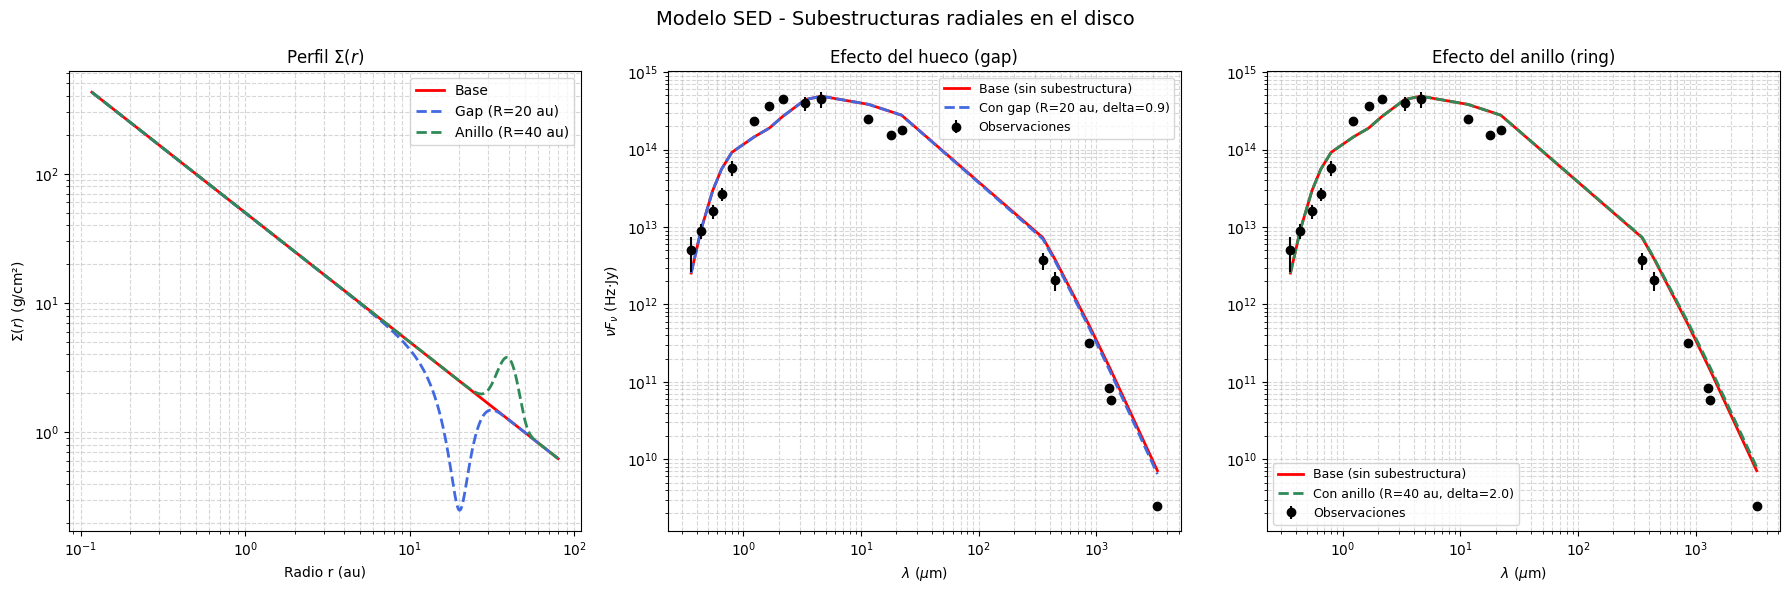

In [19]:
#Finalmente, graficamos nuevamente en 3 subplots comparativos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Modelo SED - Subestructuras radiales en el disco", fontsize=14)

r_au = r_radio / AU

#Perfil de densidad superficial donde vemos el efecto del gap y el anillo
ax = axes[0]
ax.plot(r_au, sigma_disco(r_radio), color="red", lw=2, label="Base")
ax.plot(r_au, sigma_disco(r_radio)*f_gap(r_radio), color="royalblue", lw=2, ls="--", label=f"Gap (R={R_gap/AU:.0f} au)")
ax.plot(r_au, sigma_disco(r_radio)*f_ring(r_radio), color="seagreen",  lw=2, ls="--", label=f"Anillo (R={R_ring/AU:.0f} au)")
ax.set_xlabel("Radio r (au)")
ax.set_ylabel(r"$\Sigma(r)$ (g/cm²)")
ax.set_title(r"Perfil $\Sigma(r)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)

#SED con gap vs base
ax = axes[1]
ax.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error,
            fmt="o", color="black", label="Observaciones", zorder=5)
ax.plot(data["wavelength"], sed_base, color="red", lw=2, label="Base (sin subestructura)")
ax.plot(data["wavelength"], sed_gap,  color="royalblue", lw=2, ls="--", label=f"Con gap (R={R_gap/AU:.0f} au, delta={delta_gap})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ ($\mu$m)")
ax.set_ylabel(r"$\nu F_\nu$ (Hz·Jy)")
ax.set_title("Efecto del hueco (gap)")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls="--", alpha=0.5)

#SED con anillo vs base
ax = axes[2]
ax.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error,
            fmt="o", color="black", label="Observaciones", zorder=5)
ax.plot(data["wavelength"], sed_base, color="red", lw=2, label="Base (sin subestructura)")
ax.plot(data["wavelength"], sed_ring, color="seagreen", lw=2, ls="--", label=f"Con anillo (R={R_ring/AU:.0f} au, delta={delta_ring})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ ($\mu$m)")
ax.set_title("Efecto del anillo (ring)")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Análisis del efecto de las subestructuras en la SED:**

Como podemos ver en los gráficos, el efecto del anillo o el hueco es bastante débil sobre la SED. Esto se debe posiblemente a que la SED integra el flujo sobre todo el disco, de forma que la distribución de masa en pocas distancias produce variaciones pequeñas.

Un hueco profundo en el infrarrojo lejano podría modificar con mayor impacto la SED en forma de déficit, mientras que un anillo denso puede añadir un leve exceso.

## Parte 5: Optimización de parámetros con MCMC

Implementamos un método de inferencia estadística para estimar los parámetros principales utilizando `emcee`  Los parámetros libres son:

| Parámetro | Descripción | Prior |
|-----------|-------------|-------|
| $\log_{10}\Sigma_1$ | Densidad superficial midplane a 1 au [g/cm²] | Uniforme [0, 3] |
| $T_1$ [K] | Temperatura midplane a 1 au | Uniforme [100, 600] + Gaussiano centrado en 300 K |
| $\log_{10}(\Sigma_2/\Sigma_1)$ | Razón de densidades superficiales | Uniforme [−2, 1] |
| $T_2$ [K] | Temperatura de la capa superficial a 1 au | Uniforme [50, 2000] |
| $\beta$ | Índice espectral de opacidad | Uniforme [0.5, 2.5] |

Donde el radio mínimo $R_{\min}$ se deriva en cada paso del MCMC a partir de $T_1$ y la condición de sublimación (en vez de ser un parámetro libre).

In [20]:
warnings.filterwarnings("ignore") #Ignoramos advertencias

#Los datos observacionales son
obs_nuFnu = nu_Fnu.values #Hz * Jy
obs_nuFnu_err = nu_Fnu_error.values #Hz * Jy

#Los parámetros fijos durante el MCMC (los que no vamos a variar)
mcmc_fixed = dict(
    T_1=T_1, T_2=T_2,
    R_1=R_1, R_2=R_2,
    d_cm=d_cm, cos_i=cos_i,
    q1=q1, q2=q2,
    R_min=R_min,
    A_v=1.5,
    R_max = 80 * AU, #Este es el valor base, pero lo dejamos fijo para el MCMC
)

#Nombres para los parámetros
param_names = [
    r"$\log_{10}\Sigma_1$",
    r"$T_1$ [K]",
    r"$\log_{10}(\Sigma_2/\Sigma_1)$",
    r"$T_2$ [K]",
    r"$\beta$",
]

#Las priors uniformes para cada parámetro (en el mismo orden que param_names)
prior_bounds = [
    (0.0,  3.0), #log10(sigma1)
    (100., 600.), #T1
    (-2.0, 1.0), #log10(sigma2/sigma1)
    (50., 2000.), #T2
    (0.5,  2.5), #beta
]

def theta_to_params(theta):
    """
    Convierte el vector de parámetros MCMC al diccionario que acepta modelo_SED.
    """
    log_s1, T1d, log_ratio, T2d, bet = theta
    
    params = dict(mcmc_fixed) 
    params["sigma1"] = 10**log_s1
    params["sigma2"] = 10**log_s1 * 10**log_ratio #Sigma2 = Sigma1 * ratio
    params["T1_disco"] = T1d
    params["T2_disco"] = T2d
    params["beta"] = bet
    
    #Calculamos el R_min derivado de la temperatura en cada paso del MCMC
    params["R_min"] = r1 * (T1d / T_sub) ** (1.0 / q1)
    
    return params

#Prior gaussiano sobre T1 centrado en el valor que podemos ajustar
T1_prior_mean = 300.0
T1_prior_std  = 80.0
def log_prior(theta):
    log_s1, T1d, log_ratio, T2d, bet = theta
    
    #Aquí tenemos las priors uniformes
    for val, (lo, hi) in zip(theta, prior_bounds):
        if not (lo <= val <= hi):
            return -np.inf
            
    #Se establece la condición física del proyecto, es decir, que el componente 2 debe ser más caliente que el 1 (T2 > T1)
    if T2d <= T1d * 1.2:
        return -np.inf
    #Prior gaussiano sobre T1
    lp_T1 = -0.5 * ((T1d - T1_prior_mean) / T1_prior_std)**2
    return lp_T1

def log_likelihood(theta):
    params = theta_to_params(theta)
    try:
        mod_nuFnu = modelo_SED(frecuencias, data, **params)
    except Exception:
        return -np.inf
        
    if np.any(~np.isfinite(mod_nuFnu)) or np.any(mod_nuFnu <= 0):
        return -np.inf
        
    residuals = (obs_nuFnu - mod_nuFnu) / obs_nuFnu_err
    return -0.5 * np.sum(residuals**2)

def log_posterior(theta):
    """
    Se calcula el log-posterior como la suma del log-prior y el log-likelihood.
    Log-posterior = log-prior + log-likelihood.
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

#Mostramos en pantalla, para verificación, que las funciones de MCMC están definidas correctamente
print("Funciones de MCMC definidas correctamente.")


Funciones de MCMC definidas correctamente.


In [ ]:
#Configuración del sampler
ndim = len(prior_bounds) #5 parámetros libres
nwalkers = 64 #número de walkers (debe ser >= 2*ndim)
nburn = 1500 #pasos de burn-in
nsteps = 6000 #pasos de producción

#Punto inicial: valores del modelo ajustado a "ojo"
p0_center = np.array([
    np.log10(sigma1),
    T1_disco,
    np.log10(sigma2/sigma1),
    T2_disco,
    beta,
])

#Perturbamos levemente de forma gaussiana para inicializar los walkers y dispersarlos en torno al punto incial
rng  = np.random.default_rng(42)
p0   = p0_center + rng.normal(0, 0.08, size=(nwalkers, ndim)) * np.abs(p0_center)

#Nos aseguramos de que ningún walker empiece fuera de los priors
for i in range(nwalkers):
    for j, (lo, hi) in enumerate(prior_bounds):
        p0[i, j] = np.clip(p0[i, j], lo + 1e-6, hi - 1e-6) #Recortamos

#Para cada fase e iniciación de MCMC, imprimimos un mensaje para saber como va el proceso y tener el tiempo total estimado
print(f"Iniciando MCMC: {nwalkers} walkers x {nburn + nsteps} pasos ({ndim} parámetros)")
print(f"Punto inicial: {p0_center}")

#Fase de burn-in
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

print("\nFase burn-in...")
state = sampler.run_mcmc(p0, nburn, progress=True)
sampler.reset()

#Fase de producción
print("\nFase de producción...")
sampler.run_mcmc(state, nsteps, progress=True)

print("\nMCMC completado.")
print(f"Tasa de aceptación media: {np.mean(sampler.acceptance_fraction):.3f}")

Iniciando MCMC: 64 walkers x 7500 pasos (5 parámetros)
Punto inicial: [  1.69897 300.       -1.      400.        1.     ]

Fase burn-in...


100%|██████████| 1500/1500 [02:56<00:00,  8.52it/s]



Fase de producción...


100%|██████████| 6000/6000 [11:25<00:00,  8.76it/s]


MCMC completado.
Tasa de aceptación media: 0.501


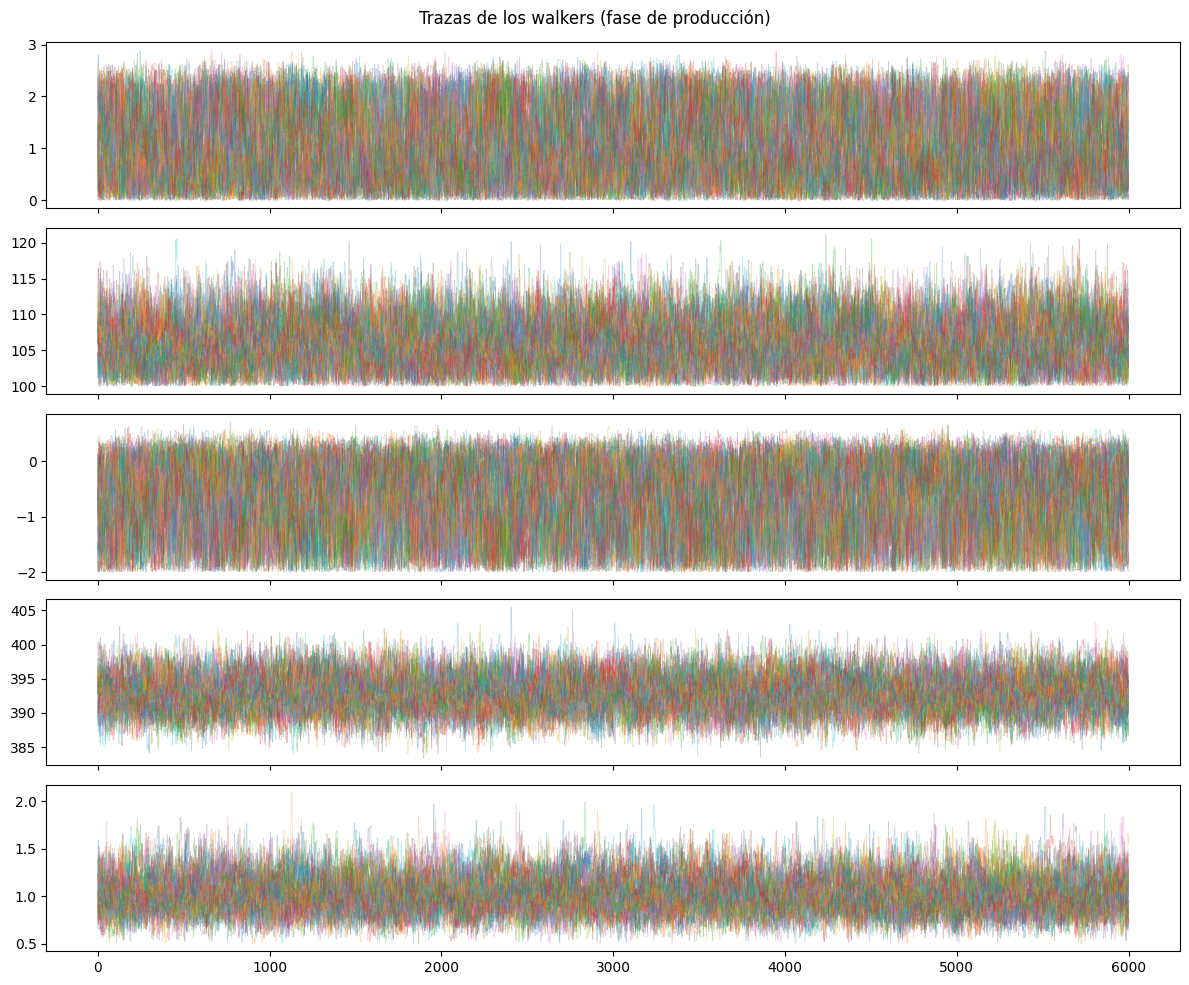

Tiempos de autocorrelación estimados:
  $\log_{10}\Sigma_1$           : 73.6 pasos
  $T_1$ [K]                     : 65.2 pasos
  $\log_{10}(\Sigma_2/\Sigma_1)$: 72.3 pasos
  $T_2$ [K]                     : 63.6 pasos
  $\beta$                       : 71.3 pasos

Muestras independientes efectivas aprox.: 82


In [ ]:
#Diagnóstico de convergencia: trazas de los walkers
fig, axes = plt.subplots(ndim, figsize=(12, 2*ndim), sharex=True)
samples_raw = sampler.get_chain() #shape (nsteps, nwalkers, ndim)

#Graficamos las trazas de los walker con diferentes colores para distinguirlos mejor
for i in range(nwalkers):
    for j in range(ndim):
        axes[j].plot(samples_raw[:, i, j], alpha=0.3, lw=0.5)
fig.suptitle("Trazas de los walkers (fase de producción)", fontsize=12)
plt.tight_layout()
plt.show()

#Tiempos de autocorrelación (es un diagnóstico de mezcla del sampler)
try:
    tau = sampler.get_autocorr_time(quiet=True)
    print("Tiempos de autocorrelación estimados:")
    for name, t in zip(param_names, tau):
        print(f" {name:30s}: {t:.1f} pasos")
    print(f"\nMuestras independientes efectivas aprox.: {nsteps / np.max(tau):.0f}")
except Exception as e:
    print(f"No se pudo calcular tau_autocorr: {e}")


Parámetros inferidos (mediana $\pm 1 \sigma$):
 log10(s1)       =    0.939  (+0.940 / -0.646)
 T1 [K]          =  105.735  (+3.512 / -3.163)
 log10(s2)       =   -0.569  (+0.625 / -0.856)
 T2 [K]          =  392.728  (+2.590 / -2.497)
 beta            =    0.998  (+0.196 / -0.163)

 Sigma1  = 8.69 g/cm^2 (+1.70 / -1.42)
 Sigma2  = 2.346 g/cm^2


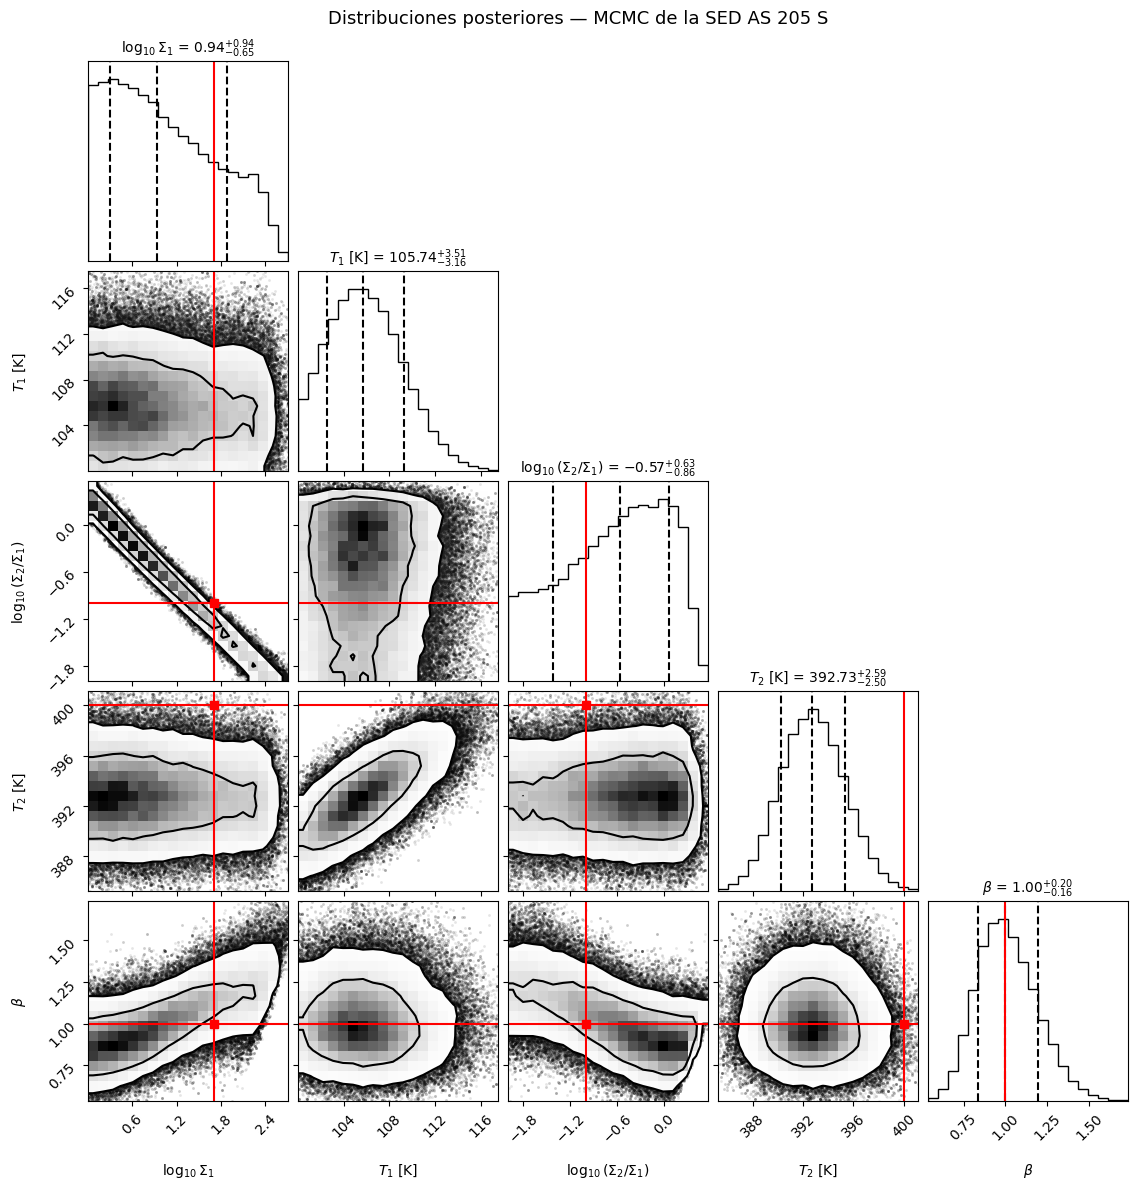

In [23]:
#Parte donde se extraen muestras planas y estimación de parámetros
flat_samples = sampler.get_chain(flat=True)

#Valores óptimos (mediana) e incertidumbres
quantiles = np.percentile(flat_samples, [16, 50, 84], axis=0)
theta_best = quantiles[1]
sigma_lo = quantiles[1] - quantiles[0]
sigma_hi = quantiles[2] - quantiles[1]

#Convertimos de log a unidades físicas tanto para Sigma1 como para Sigma2
sigma1_best = 10**theta_best[0]
sigma2_best = 10**(theta_best[0] + theta_best[2])
sigma1_lo = sigma1_best - 10**quantiles[0][0]
sigma1_hi = 10**quantiles[2][0] - sigma1_best
sigma2_lo = sigma2_best - 10**(quantiles[0][0] + quantiles[0][2])
sigma2_hi = 10**(quantiles[2][0] + quantiles[2][2]) - sigma2_best

print("=" * 60)
print(r"Parámetros inferidos (mediana $\pm 1 \sigma$):")
print("=" * 60)
labels_plain = ["log10(s1)", "T1 [K]", "log10(s2)", "T2 [K]", "beta"]
for name, val, lo, hi in zip(labels_plain, theta_best, sigma_lo, sigma_hi):
    print(f" {name:15s} = {val:8.3f}  (+{hi:.3f} / -{lo:.3f})")
print()
print(f" Sigma1  = {10**theta_best[0]:.2f} g/cm^2 (+{10**theta_best[0]*hi:.2f} / -{10**theta_best[0]*lo:.2f})")
sigma2_best = 10**(theta_best[0] + theta_best[2])
print(f" Sigma2  = {sigma2_best:.3f} g/cm^2")

#Obtenemos el R_min derivado del mejor T1
R_min_best = r1 * (theta_best[1] / T_sub) ** (1.0 / q1)

#Gráficos de Corner plots
fig_corner = corner.corner(
    flat_samples,
    labels=param_names,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 10},
    truths=p0_center,
    truth_color="red",
    plot_datapoints=True,
    fill_contours=False,
    levels=(0.68, 0.95),
    color="black",
    range=[0.999]*ndim
)
fig_corner.suptitle("Distribuciones posteriores — MCMC de la SED AS 205 S", y=1.01, fontsize=13)
plt.show()

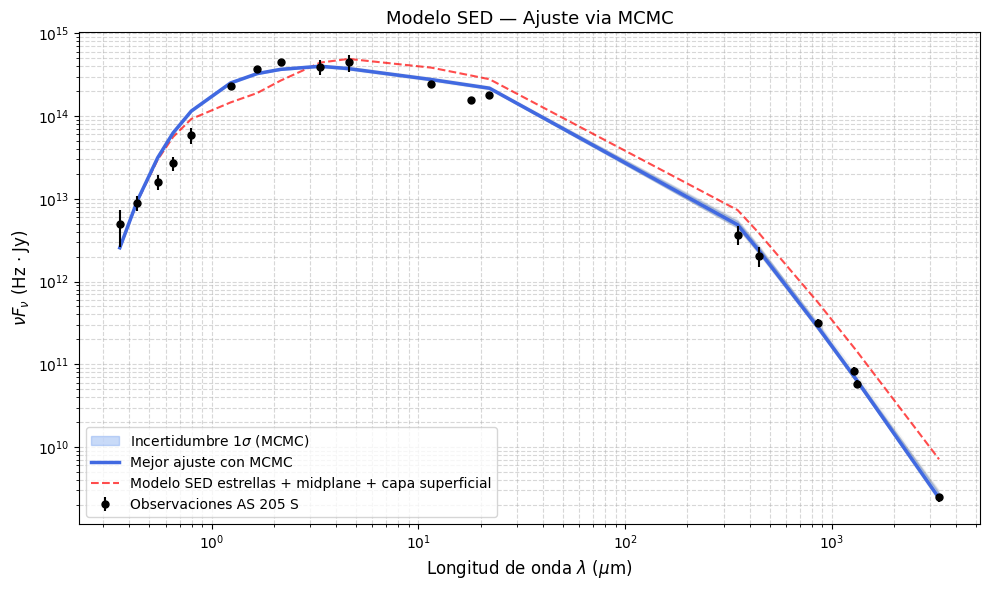


Tabla de Parámetros Inferidos por MCMC
Parámetro                    Mediana    -1sigma    +1sigma
-----------------------------------------------------------------
$\Sigma_1$ [g/cm$^2$]          8.694      6.732     67.018
$T_1$ [K]                    105.735      3.163      3.512
$\Sigma_2$ [g/cm$^2$]          2.346      2.272     83.847
$T_2$ [K]                    392.728      2.497      2.590
$\beta$                        0.998      0.163      0.196
$R_{min}$ [au]                 0.029      0.000      0.000

Parámetros fijos durante el MCMC:
$T_{\star,1} = 4200.0 K,  T_{\star,2} = 3800.0 K$
L_{\star,1} = 1.0 $L_\odot$,  L_{\star,2} = 0.4 $L_\odot$
i = 68.0º, d = 127 pc
$q_1$ = 0.75, $q_2$ = 0.55


In [24]:
#Finalmente graficamos la SED del mejor ajuste
sed_best = modelo_SED(frecuencias, data, **theta_to_params(theta_best))

n_realiz = 200
idx_realiz = rng.integers(0, flat_samples.shape[0], size=n_realiz)
sed_realiz = np.array([
    modelo_SED(frecuencias, data, **theta_to_params(flat_samples[i]))
    for i in idx_realiz
])
sed_lo = np.percentile(sed_realiz, 16, axis=0)
sed_hi = np.percentile(sed_realiz, 84, axis=0)

#Gráfico final
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(data["wavelength"], nu_Fnu, yerr=nu_Fnu_error,
            fmt="o", color="black", zorder=10,
            label="Observaciones AS 205 S", markersize=5)

ax.fill_between(data["wavelength"], sed_lo, sed_hi,
                color="cornflowerblue", alpha=0.35,
                label=r"Incertidumbre $1\sigma$ (MCMC)")

for s in sed_realiz[::10]:
    ax.plot(data["wavelength"], s, color="gray", alpha=0.08, lw=0.8)

ax.plot(data["wavelength"], sed_best, color="royalblue", lw=2.5,
        label="Mejor ajuste con MCMC", zorder=9)

ax.plot(data["wavelength"], frecuencias * F_modelo_total_Jy,
        ls="--", color="red", lw=1.5, alpha=0.7, 
        label=r"Modelo SED estrellas + midplane + capa superficial")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Longitud de onda $\lambda$ ($\mu$m)", fontsize=12)
ax.set_ylabel(r"$\nu F_\nu$ (Hz $\cdot$ Jy)", fontsize=12)
ax.set_title(r"Modelo SED — Ajuste via MCMC", fontsize=13)

ax.legend(fontsize=10)
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

#Mostramos la tabla de parámetros inferidos por MCMC
print("\n" + "=" * 65)
print("Tabla de Parámetros Inferidos por MCMC")
print("=" * 65)
header = f"{'Parámetro':<25} {'Mediana':>10} {'-1sigma':>10} {'+1sigma':>10}"
print(header)
print("-" * 65)

rows = [
    (r"$\Sigma_1$ [g/cm$^2$]", sigma1_best, sigma1_lo, sigma1_hi),
    (r"$T_1$ [K]", theta_best[1], sigma_lo[1], sigma_hi[1]),
    (r"$\Sigma_2$ [g/cm$^2$]", sigma2_best,  sigma2_lo,  sigma2_hi),
    (r"$T_2$ [K]", theta_best[3], sigma_lo[3], sigma_hi[3]),
    (r"$\beta$", theta_best[4], sigma_lo[4], sigma_hi[4]),
    (r"$R_{min}$ [au]", R_min_best/AU, 0.0, 0.0),
]

for name, val, lo, hi in rows:
    print(f"{name:<25} {val:>10.3f} {lo:>10.3f} {hi:>10.3f}")

print("=" * 65)
print("\nParámetros fijos durante el MCMC:")
print(rf"$T_{{\star,1}} = {T_1} K,  T_{{\star,2}} = {T_2} K$")
print(rf"L_{{\star,1}} = {L_1/L_sun:.1f} $L_\odot$,  L_{{\star,2}} = {L_2/L_sun:.1f} $L_\odot$")
print(f"i = {i_deg}º, d = {d_pc} pc")
print(rf"$q_1$ = {q1}, $q_2$ = {q2}")

## Discusión: degeneraciones y restricciones

### Parámetros mejor restringidos

- **$\beta$** (índice espectral de opacidad): está bien definido por los puntos milimétricos de ALMA/DSHARP, que son muy sensibles a la pendiente espectral en el régimen de Rayleigh-Jeans ópticamente delgado.
- **$T_1$ y $T_2$**: moderadamente bien restringidos por el pico y la pendiente del exceso infrarrojo, aunque el prior gaussiano sobre $T_1$ también contribuye a lograr definir mejor su posterior.

### Parámetros peor restringidos

- **$\Sigma_1$ y $\Sigma_2$**: presentan una degeneración entre sí, ya que ambos contribuyen al flujo total del disco. Un aumento de $\Sigma_1$ puede compensarse parcialmente con una disminución de $\Sigma_2$ manteniendo el flujo integrado similar.
- **$R_{\max}$** (fijado en este modelo): si se dejara libre, estaría poco restringido por la SED, ya que las regiones más frías del disco externo aportan principalmente en el milimétrico donde los datos son escasos.

### Pregunta conceptual: ¿La SED puede distinguir una estrella de una binaria no resuelta?

En general, no de forma muy apropiada. La SED integra el flujo de todas las fuentes, y dos configuraciones muy diferentes de $(T_{\star,1}, R_{\star,1}, T_{\star,2}, R_{\star,2})$ pueden producir práctimente la misma SED total. Esto sucede sobre todo cuando las temperaturas de ambas estrellas son muy similares.

**Disclaimer sobre el uso de herramientas de IA:** En la elaboración de este proyecto se utilizó Claude como asistente para la redacción de celdas explicativas en formato Markdown, revisiones matemáticas y depuraciones puntuales del código, declarada por transparencia. Los criterios de modelos, parámetros y los análisis de resultados fueron desarrollados puramente por nosotros.